# Notebook 2 — Exploratory Data Analysis (EDA)
## BRFSS 2022 Heart Disease Prediction

---

**Input:** `brfss2022_clean.csv` — output từ Notebook 1 (đã cleaned & encoded)

**Output:** 5 biểu đồ EDA phân tích dataset

**Mục tiêu:**
- Hiểu phân phối target variable (class imbalance)
- Phân tích Demographics vs CVD risk
- Phân tích Clinical factors vs CVD risk
- Phân tích Correlation giữa các features
- Phân tích Lifestyle factors vs CVD risk

---

### Dataset Summary (từ NB1)

| Thông tin | Giá trị |
|---|---|
| Total records | 340,154 |
| Features | 50 cột |
| Target | `target` — CVD/MI (1=Có, 0=Không) |
| CVD Positive | 30,255 (8.89%) |
| Class Imbalance | 10.2:1 |

## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Output folder
import os
OUT = '/content/nb2_outputs'
os.makedirs(OUT, exist_ok=True)

print('✓ Libraries loaded')

✓ Libraries loaded


In [ ]:
# Upload brfss2022_clean.csv lên Colab trước khi chạy cell này
from google.colab import files
uploaded = files.upload()   # chọn brfss2022_clean.csv

df = pd.read_csv('brfss2022_clean.csv')
print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'   Target distribution:')
print(df['target'].value_counts().to_string())
df.head(3)

Saving brfss2022_clean.csv to brfss2022_clean.csv
✅ Dataset loaded: 340,154 rows × 51 cols
   Target distribution:
target
0    309899
1     30255


,target,Male,Age_18_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_plus,Sleep_hours,Physical_activity,...,Emp_homemaker,Emp_student,Emp_retired,Emp_unable,Race_white,Race_black,Race_am_indian,Race_asian,Race_pacific,Race_hispanic
0,0,0,0,0,0,0,0,1,6.0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,1,0,5.0,1,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,7.0,1,...,0,0,1,0,1,0,0,0,0,0


---

## 2. Chart 1 — Target Distribution (Class Imbalance)

**Purpose:** Visualize the imbalance between the two classes.

**Insight:** The dataset has an imbalance ratio of **10.2:1** (No CVD vs CVD) → **SMOTE** will need to be applied in Notebook 3 to balance the model before training.

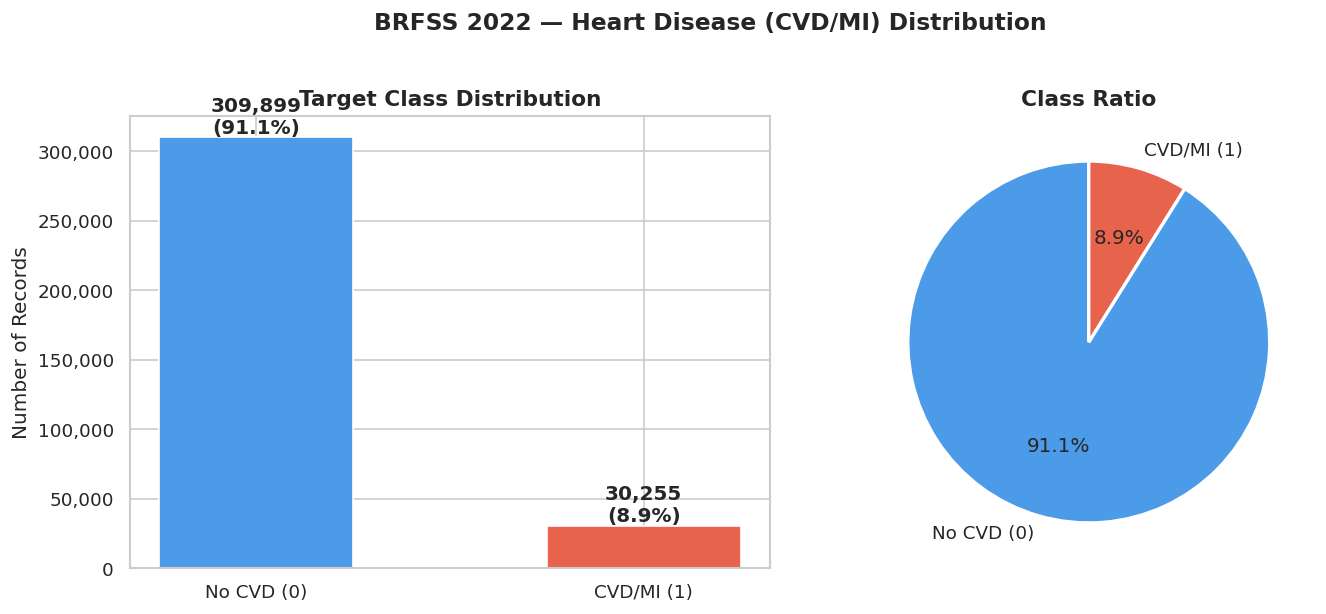

📊 Class imbalance ratio: 10.2:1
   → Cần SMOTE để cân bằng dataset trước khi train model


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts()
labels = ['No CVD (0)', 'CVD/MI (1)']
colors = ['#4C9BE8', '#E8634C']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Ratio', fontweight='bold', fontsize=13)

plt.suptitle('BRFSS 2022 — Heart Disease (CVD/MI) Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/fig1_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'📊 Class imbalance ratio: {counts[0]/counts[1]:.1f}:1')
print(f'   → Cần SMOTE để cân bằng dataset trước khi train model')

---
## 3. Chart 2 — Demographics: Age Group & Gender vs CVD Risk

**Purpose:** To compare CVD rates by age group and gender.

**Insight:**
- CVD rates increase progressively with age — the 65+ group has the highest risk.
- **Men** have higher CVD rates than women.

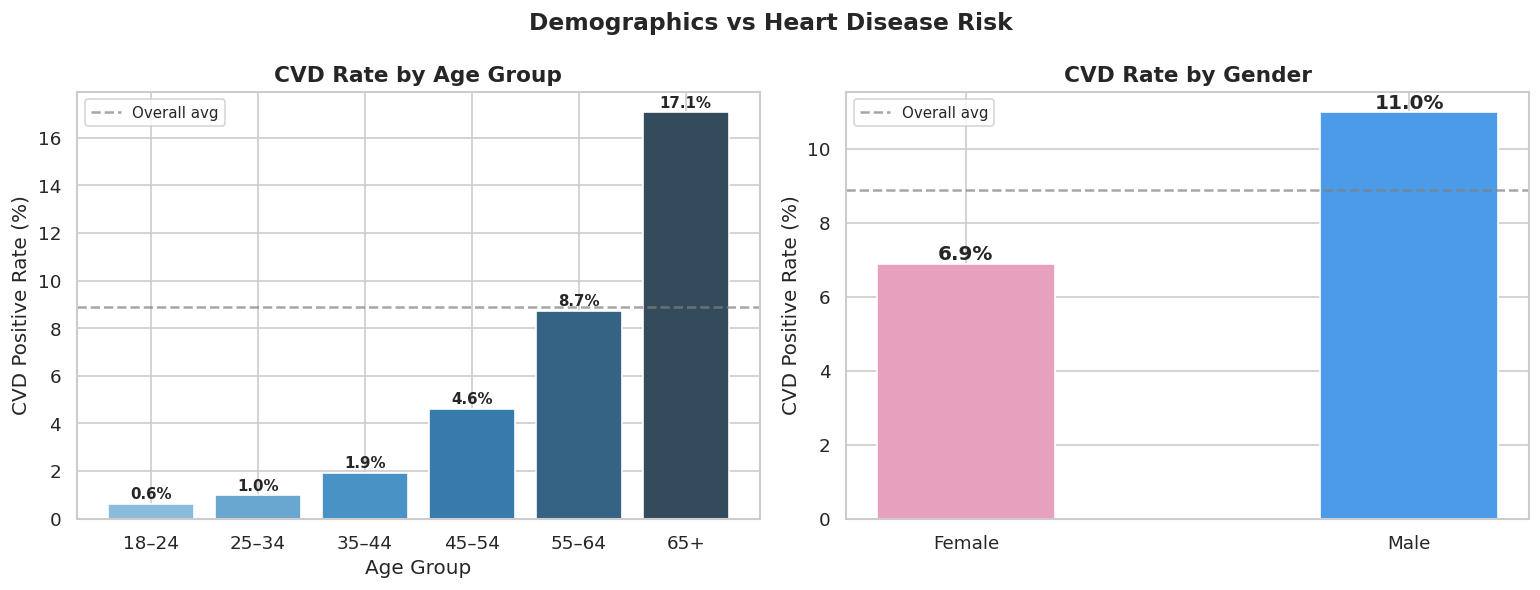

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age group CVD rate
age_cols   = ['Age_18_24','Age_25_34','Age_35_44','Age_45_54','Age_55_64','Age_65_plus']
age_labels = ['18–24','25–34','35–44','45–54','55–64','65+']

cvd_rate = [df[df[col]==1]['target'].mean()*100 for col in age_cols]

bars = axes[0].bar(age_labels, cvd_rate,
                   color=sns.color_palette('Blues_d', len(age_cols)),
                   edgecolor='white')
axes[0].set_title('CVD Rate by Age Group', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('CVD Positive Rate (%)')
axes[0].axhline(y=df['target'].mean()*100, color='gray',
                linestyle='--', alpha=0.7, label='Overall avg')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, cvd_rate):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Gender CVD rate
gender_rate   = df.groupby('Male')['target'].mean() * 100
gender_labels = ['Female', 'Male']
axes[1].bar(gender_labels, gender_rate.values,
            color=['#E8A0BF', '#4C9BE8'],
            edgecolor='white', width=0.4)
axes[1].set_title('CVD Rate by Gender', fontweight='bold', fontsize=13)
axes[1].set_ylabel('CVD Positive Rate (%)')
axes[1].axhline(y=df['target'].mean()*100, color='gray',
                linestyle='--', alpha=0.7, label='Overall avg')
axes[1].legend(fontsize=9)
for i, val in enumerate(gender_rate.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Demographics vs Heart Disease Risk',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/fig2_demographics.png', bbox_inches='tight')
plt.show()

---
## 4. Chart 3 — Clinical Risk Factors vs CVD Rate

**Objective:** To compare CVD rates between individuals with and without underlying medical conditions.

**Insights:**

- Stroke and COPD had the highest CVD rates among patients with these conditions.

- All underlying medical conditions significantly increased CVD risk compared to the group without them.

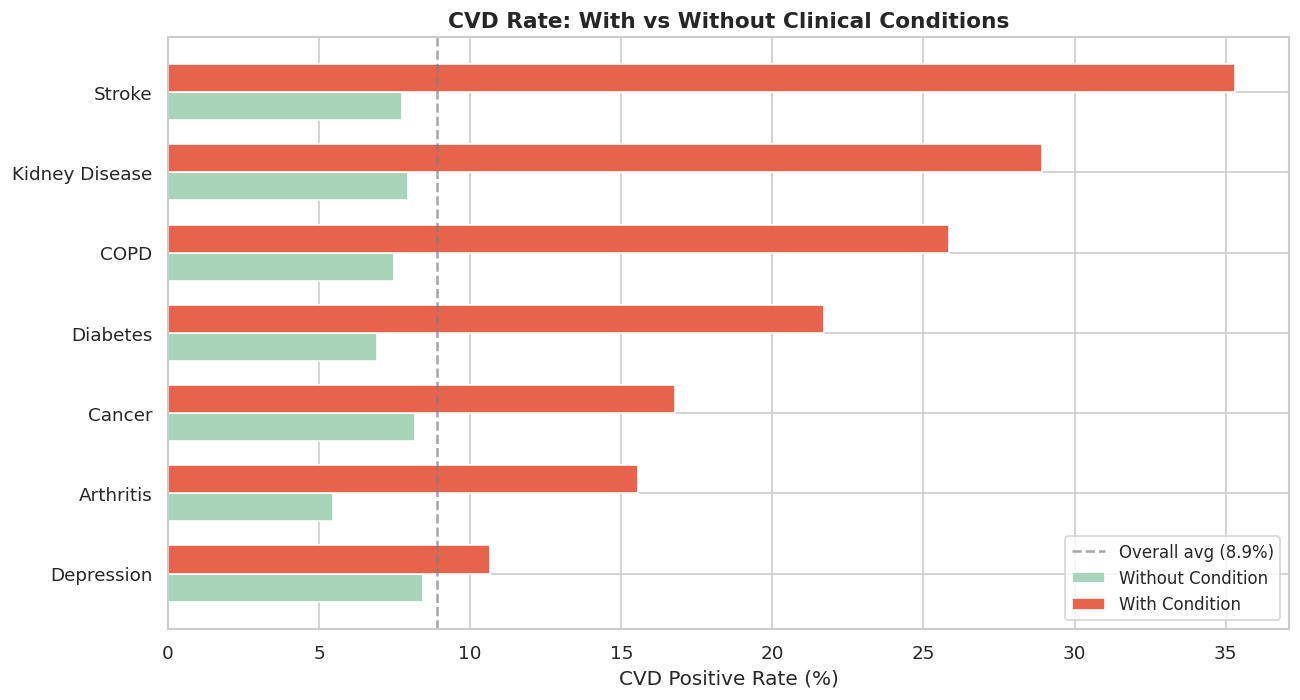

📊 CVD rate by clinical condition (sorted):
                CVD Rate (%) with condition
Depression                        10.648754
Arthritis                         15.539157
Cancer                            16.762823
Diabetes                          21.718497
COPD                              25.858917
Kidney Disease                    28.924266
Stroke                            35.323843


In [ ]:
clinical_cols = {
    'Stroke':         'Stroke',
    'COPD':           'COPD',
    'Diabetes_yes':   'Diabetes',
    'Kidney_disease': 'Kidney Disease',
    'Arthritis':      'Arthritis',
    'Depression':     'Depression',
    'Cancer':         'Cancer'
}

rates = {}
for col, label in clinical_cols.items():
    rates[label] = {
        'With Condition':    df[df[col]==1]['target'].mean() * 100,
        'Without Condition': df[df[col]==0]['target'].mean() * 100
    }

rate_df = pd.DataFrame(rates).T.sort_values('With Condition', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x     = np.arange(len(rate_df))
width = 0.35

ax.barh(x - width/2, rate_df['Without Condition'], width,
        label='Without Condition', color='#A8D5BA', edgecolor='white')
ax.barh(x + width/2, rate_df['With Condition'],    width,
        label='With Condition',    color='#E8634C', edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(rate_df.index, fontsize=11)
ax.set_xlabel('CVD Positive Rate (%)')
ax.set_title('CVD Rate: With vs Without Clinical Conditions',
             fontweight='bold', fontsize=13)
ax.axvline(x=df['target'].mean()*100, color='gray',
           linestyle='--', alpha=0.7, label=f'Overall avg ({df["target"].mean()*100:.1f}%)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUT}/fig3_clinical_factors.png', bbox_inches='tight')
plt.show()

print('📊 CVD rate by clinical condition (sorted):')
print(rate_df[['With Condition']].rename(
    columns={'With Condition': 'CVD Rate (%) with condition'}).to_string())

---
## 5. Chart 4 — Feature Correlation Heatmap

**Purpose:** To analyze the correlation between features and targets.

**Insight:**

- **Age_65_plus**, **Stroke**, **GenHealth_poor** have the strongest positive correlation with CVD.
- **Physical_activity**, **GenHealth_excellent** have a negative correlation (reduced risk).
- Some features exhibit multicollinearity (e.g., GenHealth columns).

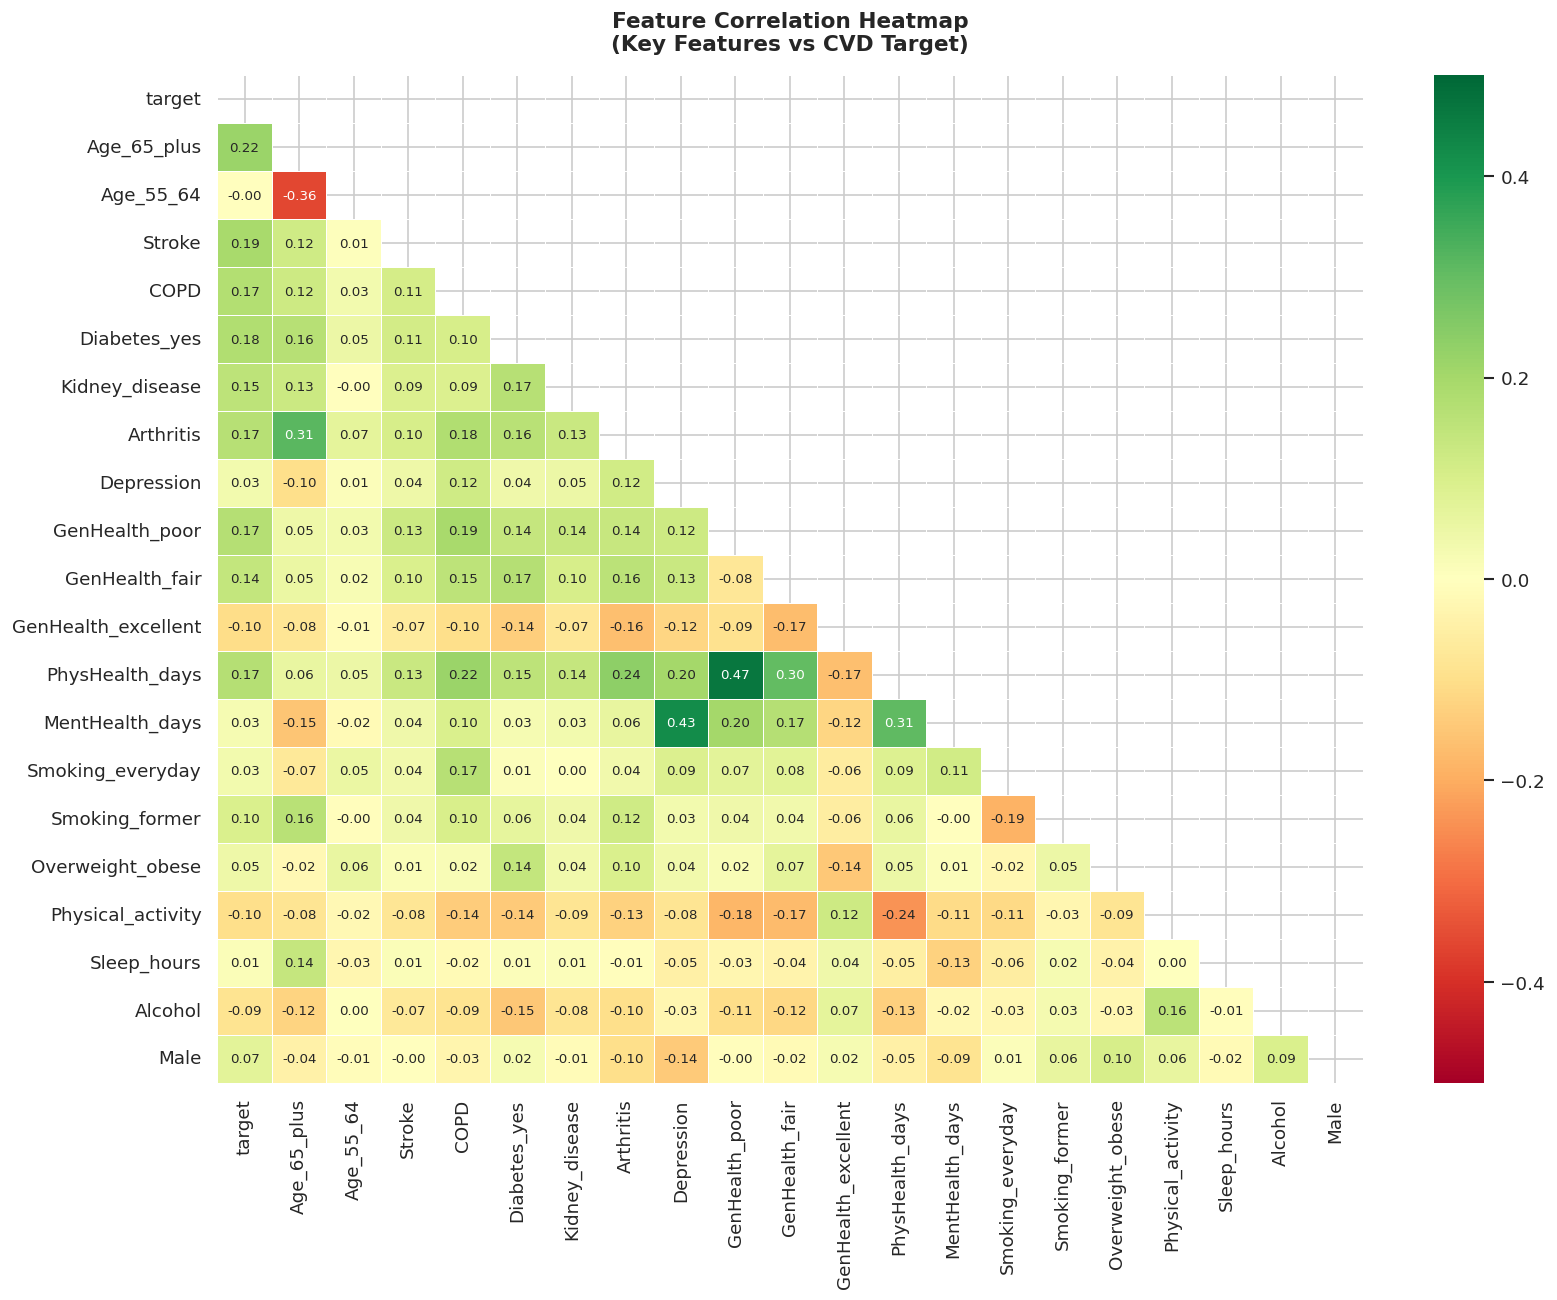

🔥 Top 10 features correlated with CVD target:
   + Age_65_plus               r = +0.216
   + Stroke                    r = +0.193
   + Diabetes_yes              r = +0.178
   + COPD                      r = +0.172
   + PhysHealth_days           r = +0.170
   + GenHealth_poor            r = +0.169
   + Arthritis                 r = +0.168
   + Kidney_disease            r = +0.153
   + GenHealth_fair            r = +0.141
   - GenHealth_excellent       r = -0.103


In [ ]:
key_features = [
    'target', 'Age_65_plus', 'Age_55_64', 'Stroke', 'COPD',
    'Diabetes_yes', 'Kidney_disease', 'Arthritis', 'Depression',
    'GenHealth_poor', 'GenHealth_fair', 'GenHealth_excellent',
    'PhysHealth_days', 'MentHealth_days',
    'Smoking_everyday', 'Smoking_former',
    'Overweight_obese', 'Physical_activity',
    'Sleep_hours', 'Alcohol', 'Male'
]

corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # chỉ hiện nửa dưới

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})

ax.set_title('Feature Correlation Heatmap\n(Key Features vs CVD Target)',
             fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f'{OUT}/fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations với target
top_corr = (corr['target'].drop('target')
              .abs()
              .sort_values(ascending=False)
              .head(10))
print('🔥 Top 10 features correlated with CVD target:')
for feat, val in top_corr.items():
    direction = '+' if corr['target'][feat] > 0 else '-'
    print(f'   {direction} {feat:<25} r = {corr["target"][feat]:+.3f}')

## 6. Chart 5 — Lifestyle Factors vs. CVD Risk

**Purpose:** To analyze the impact of lifestyle on CVD risk.

**Insight:**

- **Daily smokers** have a higher-than-average CVD rate.

- People with **physical activity** have a significantly lower CVD rate.

- **Sleep hours** are similarly distributed between the two groups, but the CVD group sleeps slightly less.

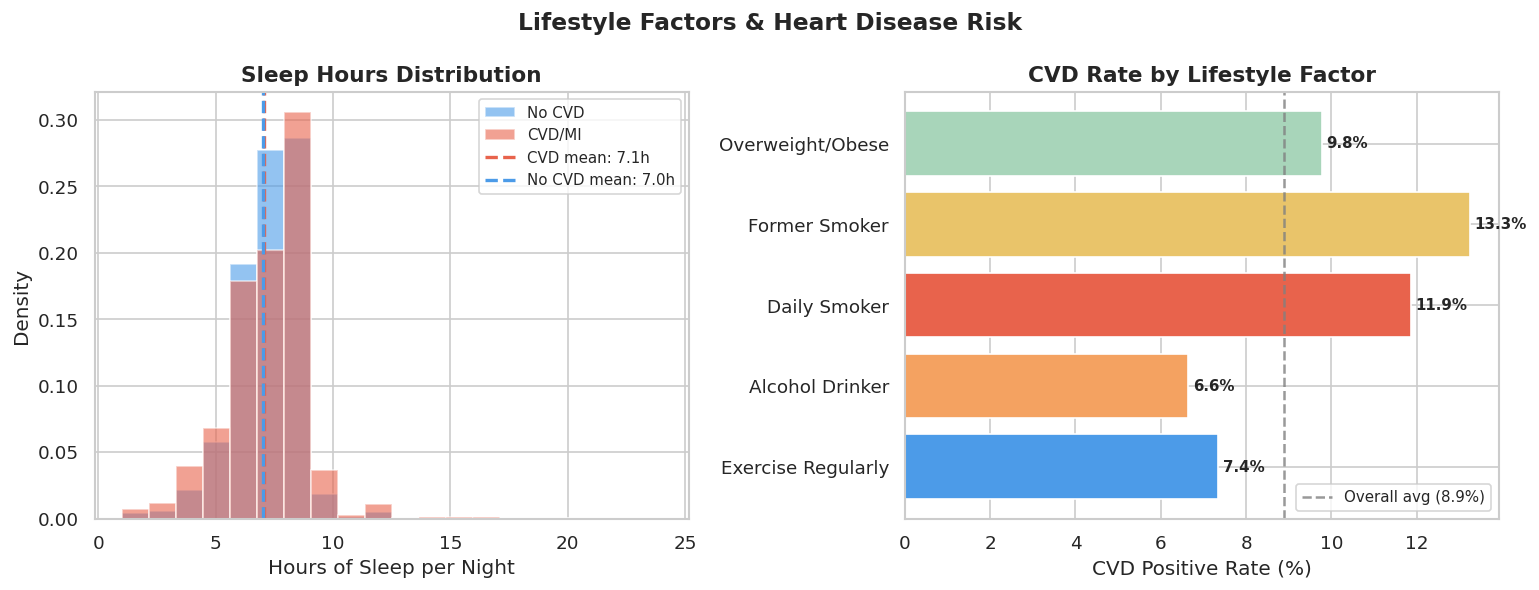

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sleep hours distribution
cvd_sleep    = df[df['target']==1]['Sleep_hours']
no_cvd_sleep = df[df['target']==0]['Sleep_hours']

axes[0].hist(no_cvd_sleep, bins=20, alpha=0.6,
             color='#4C9BE8', label='No CVD', density=True)
axes[0].hist(cvd_sleep, bins=20, alpha=0.6,
             color='#E8634C', label='CVD/MI', density=True)
axes[0].axvline(cvd_sleep.mean(), color='#E8634C', linestyle='--', linewidth=2,
                label=f'CVD mean: {cvd_sleep.mean():.1f}h')
axes[0].axvline(no_cvd_sleep.mean(), color='#4C9BE8', linestyle='--', linewidth=2,
                label=f'No CVD mean: {no_cvd_sleep.mean():.1f}h')
axes[0].set_title('Sleep Hours Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Hours of Sleep per Night')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Lifestyle binary factors — CVD rate
lifestyle_cols = {
    'Physical_activity': 'Exercise Regularly',
    'Alcohol':           'Alcohol Drinker',
    'Smoking_everyday':  'Daily Smoker',
    'Smoking_former':    'Former Smoker',
    'Overweight_obese':  'Overweight/Obese'
}
lifestyle_rates = {label: df[df[col]==1]['target'].mean()*100
                   for col, label in lifestyle_cols.items()}

overall_avg = df['target'].mean() * 100
colors_life = ['#4C9BE8','#F4A261','#E8634C','#E9C46A','#A8D5BA']
bars = axes[1].barh(list(lifestyle_rates.keys()),
                    list(lifestyle_rates.values()),
                    color=colors_life, edgecolor='white')
axes[1].axvline(x=overall_avg, color='gray', linestyle='--',
                alpha=0.8, label=f'Overall avg ({overall_avg:.1f}%)')
axes[1].set_title('CVD Rate by Lifestyle Factor', fontweight='bold', fontsize=13)
axes[1].set_xlabel('CVD Positive Rate (%)')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, lifestyle_rates.values()):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Lifestyle Factors & Heart Disease Risk',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/fig5_lifestyle.png', bbox_inches='tight')
plt.show()

---
## 7. EDA Summary

Summary of insights from 5 EDA charts:

In [ ]:
print('=' * 60)
print('EDA SUMMARY — BRFSS 2022 Heart Disease Prediction')
print('=' * 60)

print(f"""
📊 Dataset:
   Total records : {len(df):,}
   Features      : {df.shape[1]-1} cols
   CVD positive  : {df['target'].sum():,} ({df['target'].mean()*100:.2f}%)
   Imbalance     : {(1-df['target'].mean())/df['target'].mean():.1f}:1

🔍 Key Findings:
   1. Class Imbalance  → 10.2:1 → cần SMOTE ở NB3
   2. Age              → CVD rate tăng mạnh từ 55+ tuổi
   3. Gender           → Nam có risk cao hơn nữ
   4. Stroke/COPD      → Clinical factors có CVD rate cao nhất
   5. Physical activity→ Có exercise giảm CVD risk đáng kể

📁 Figures saved to: /content/nb2_outputs/
   fig1_target_distribution.png
   fig2_demographics.png
   fig3_clinical_factors.png
   fig4_correlation_heatmap.png
   fig5_lifestyle.png

➡️  Next: Notebook 3 — Model Training (Logistic, RF, XGBoost + SMOTE)
""")

EDA SUMMARY — BRFSS 2022 Heart Disease Prediction

📊 Dataset:
   Total records : 340,154
   Features      : 50 cols
   CVD positive  : 30,255 (8.89%)
   Imbalance     : 10.2:1

🔍 Key Findings:
   1. Class Imbalance  → 10.2:1 → cần SMOTE ở NB3
   2. Age              → CVD rate tăng mạnh từ 55+ tuổi
   3. Gender           → Nam có risk cao hơn nữ
   4. Stroke/COPD      → Clinical factors có CVD rate cao nhất
   5. Physical activity→ Có exercise giảm CVD risk đáng kể

📁 Figures saved to: /content/nb2_outputs/
   fig1_target_distribution.png
   fig2_demographics.png
   fig3_clinical_factors.png
   fig4_correlation_heatmap.png
   fig5_lifestyle.png

➡️  Next: Notebook 3 — Model Training (Logistic, RF, XGBoost + SMOTE)

